C:\Users\Puneeth\AppData\Local\Temp\ipykernel_15284\1476320596.py:23: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')
C:\Users\Puneeth\AppData\Local\Temp\ipykernel_15284\1476320596.py:23: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')
C:\Users\Puneeth\AppData\Local\Temp\ipykernel_15284\1476320596.py:23: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')



Validation Set Accuracy: 0.780
              precision    recall  f1-score   support

           1       0.83      0.77      0.80        26
           3       0.73      0.86      0.79        28
           4       0.76      0.76      0.76        25
           5       0.83      0.71      0.77        21

    accuracy                           0.78       100
   macro avg       0.79      0.78      0.78       100
weighted avg       0.79      0.78      0.78       100



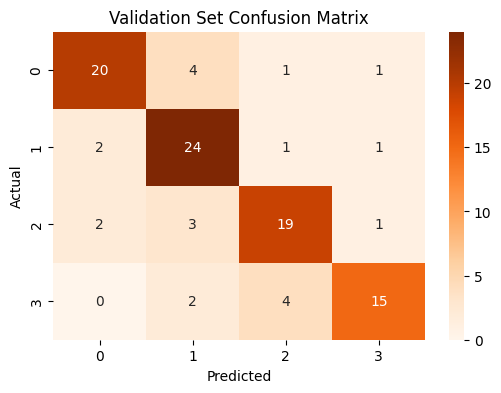

In [2]:
# ============================================
# Coral Regime Classification - SVM (Baseline)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -----------------------
# Function to load & preprocess a dataset
# -----------------------
def load_and_prepare(file_path):
    df = pd.read_csv(file_path, sep='\t', low_memory=False)
    df = df.replace(',', '.', regex=True)
    
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='ignore')

    regime_cols = [c for c in df.columns if c.lower().startswith('regime')]
    
    def get_regime_label(row):
        for i, c in enumerate(regime_cols, start=1):
            try:
                if float(row[c]) == 1:
                    return i
            except:
                continue
        return 0  # assign 0 if no regime
    
    df['Regime_Label'] = df.apply(get_regime_label, axis=1)
    
    drop_cols = ['id_spatial', 'Island', 'Long', 'Lat'] + regime_cols + ['Regime_Label']
    drop_cols = [c for c in drop_cols if c in df.columns]
    
    X = df.drop(columns=drop_cols, errors='ignore').select_dtypes(include=[np.number])
    y = df['Regime_Label']
    
    return X, y

# -----------------------
# Load datasets
# -----------------------
X_train, y_train = load_and_prepare("train.txt")
X_test, y_test = load_and_prepare("test.txt")
X_val, y_val = load_and_prepare("validation.txt")

# -----------------------
# Imputer & Scaler
# -----------------------
imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

X_train = scaler.fit_transform(imputer.fit_transform(X_train))
X_test = scaler.transform(imputer.transform(X_test))
X_val = scaler.transform(imputer.transform(X_val))

# -----------------------
# Baseline SVM
# -----------------------
svm = SVC(probability=True,kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(X_train, y_train)

# -----------------------
# Predictions
# -----------------------
y_train_pred = svm.predict(X_train)
y_test_pred = svm.predict(X_test)
y_val_pred = svm.predict(X_val)

# -----------------------
# Evaluation function
# -----------------------
def eval_model(y_true, y_pred, name="Dataset"):
    print(f"\n{name} Accuracy: {accuracy_score(y_true, y_pred):.3f}")
    print(classification_report(y_true, y_pred, zero_division=0))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# -----------------------
# Evaluate
# -----------------------

eval_model(y_val, y_val_pred, "Validation Set")


In [3]:
# ============================================
# SVM Cross-Validation on Training Data
# ============================================

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(svm, X_train, y_train, cv=5, scoring='accuracy')
print("\n==========================")
print("Cross-Validation Results (Training Data)")
print("==========================")
print("Fold Accuracies:", np.round(cv_scores, 3))
print("Mean CV Accuracy:", round(np.mean(cv_scores), 3))
print("Std Dev:", round(np.std(cv_scores), 3))



Cross-Validation Results (Training Data)
Fold Accuracies: [0.7   0.671 0.734 0.785 0.81 ]
Mean CV Accuracy: 0.74
Std Dev: 0.052


Fitting 5 folds for each of 60 candidates, totalling 300 fits

Validation Set (Tuned) Accuracy: 0.710
              precision    recall  f1-score   support

           1       0.73      0.73      0.73        26
           3       0.68      0.75      0.71        28
           4       0.67      0.72      0.69        25
           5       0.81      0.62      0.70        21

    accuracy                           0.71       100
   macro avg       0.72      0.70      0.71       100
weighted avg       0.72      0.71      0.71       100



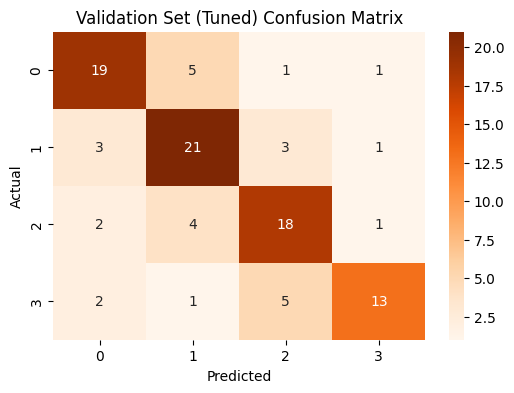


Best Parameters: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}


In [4]:
# ============================================
# SVM Hyperparameter Tuning
# ============================================

from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 50,100],
    'gamma': ['scale', 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'poly', 'sigmoid']
}

grid_search = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_svm = grid_search.best_estimator_

# Predictions on test and validation
y_test_pred_best = best_svm.predict(X_test)
y_val_pred_best = best_svm.predict(X_val)

eval_model(y_val, y_val_pred_best, "Validation Set (Tuned)")

print("\nBest Parameters:", grid_search.best_params_)


In [5]:
# ======================================================
# 🌊 Coral Regime Classifier – PCA Preprocessing
# ======================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# --------------------------
# Function to load & preprocess dataset
# --------------------------
def load_and_prepare(file_path):
    df = pd.read_csv(file_path, sep='\t', low_memory=False)
    df = df.replace(',', '.', regex=True)
    
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='ignore')

    regime_cols = [c for c in df.columns if c.lower().startswith('regime')]
    
    def get_regime_label(row):
        for i, c in enumerate(regime_cols, start=1):
            try:
                if float(row[c]) == 1:
                    return i
            except:
                continue
        return 0  # assign 0 if no regime
    
    df['Regime_Label'] = df.apply(get_regime_label, axis=1)
    
    drop_cols = ['id_spatial', 'Island', 'Long', 'Lat'] + regime_cols + ['Regime_Label']
    drop_cols = [c for c in drop_cols if c in df.columns]
    
    X = df.drop(columns=drop_cols, errors='ignore').select_dtypes(include=[np.number])
    y = df['Regime_Label']
    
    return X, y

# --------------------------
# Load datasets
# --------------------------
X_train, y_train = load_and_prepare("train.txt")
X_test, y_test = load_and_prepare("test.txt")
X_val, y_val = load_and_prepare("validation.txt")

# --------------------------
# Imputer & Scaler
# --------------------------
imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(imputer.fit_transform(X_train))
X_test_scaled = scaler.transform(imputer.transform(X_test))
X_val_scaled = scaler.transform(imputer.transform(X_val))


C:\Users\Puneeth\AppData\Local\Temp\ipykernel_15284\1078073018.py:18: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')
C:\Users\Puneeth\AppData\Local\Temp\ipykernel_15284\1078073018.py:18: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')
C:\Users\Puneeth\AppData\Local\Temp\ipykernel_15284\1078073018.py:18: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


PCA reduced 37 → 26 features for SVM

Validation Set (RBF) Results
Accuracy: 0.78
Micro F1: 0.78

Classification Report:
               precision    recall  f1-score   support

           1       0.83      0.77      0.80        26
           3       0.73      0.86      0.79        28
           4       0.76      0.76      0.76        25
           5       0.83      0.71      0.77        21

    accuracy                           0.78       100
   macro avg       0.79      0.78      0.78       100
weighted avg       0.79      0.78      0.78       100



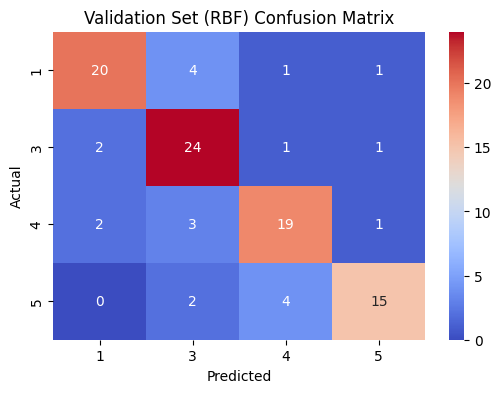


Validation Set (Poly) Results
Accuracy: 0.76
Micro F1: 0.76

Classification Report:
               precision    recall  f1-score   support

           1       0.83      0.73      0.78        26
           3       0.79      0.79      0.79        28
           4       0.65      0.88      0.75        25
           5       0.87      0.62      0.72        21

    accuracy                           0.76       100
   macro avg       0.78      0.75      0.76       100
weighted avg       0.78      0.76      0.76       100



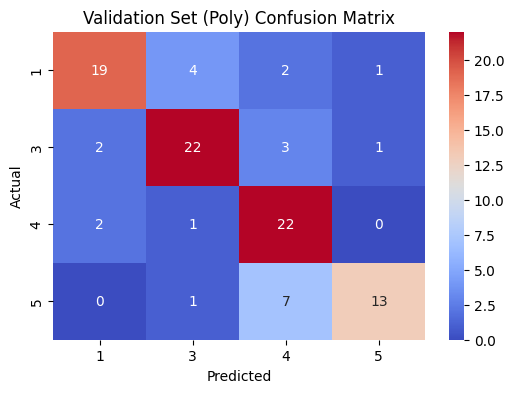

In [6]:
# ======================================================
# 🌊 SVM + PCA – Training and Evaluation
# ======================================================

from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --------------------------
# 1️⃣ PCA for SVM
# --------------------------
pca = PCA(n_components=0.95, random_state=42)   # retain 95% variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
X_val_pca = pca.transform(X_val_scaled)

print(f"PCA reduced {X_train_scaled.shape[1]} → {X_train_pca.shape[1]} features for SVM")

# --------------------------
# Evaluation function
# --------------------------
def eval_svm(y_true, y_pred, name="Dataset"):
    acc = accuracy_score(y_true, y_pred)
    micro_f1 = f1_score(y_true, y_pred, average='micro')
    print(f"\n{name} Results")
    print("==========================")
    print("Accuracy:", round(acc, 3))
    print("Micro F1:", round(micro_f1, 3))
    print("\nClassification Report:\n", classification_report(y_true, y_pred, zero_division=0))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# --------------------------
# 2️⃣ SVM RBF Kernel
# --------------------------
svm_rbf = SVC(kernel='rbf', C=1, gamma='scale', class_weight='balanced', random_state=42)
svm_rbf.fit(X_train_pca, y_train)

eval_svm(y_val, svm_rbf.predict(X_val_pca), "Validation Set (RBF)")

# --------------------------
# 3️⃣ SVM Polynomial Kernel
# --------------------------
svm_poly = SVC(kernel='poly', degree=3, C=1, gamma='scale', class_weight='balanced', random_state=42)
svm_poly.fit(X_train_pca, y_train)

eval_svm(y_val, svm_poly.predict(X_val_pca), "Validation Set (Poly)")


In [7]:
import joblib

# Example: after training
# SVM
joblib.dump(svm, "SVM_model.pkl")
joblib.dump(imputer, "imputer.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

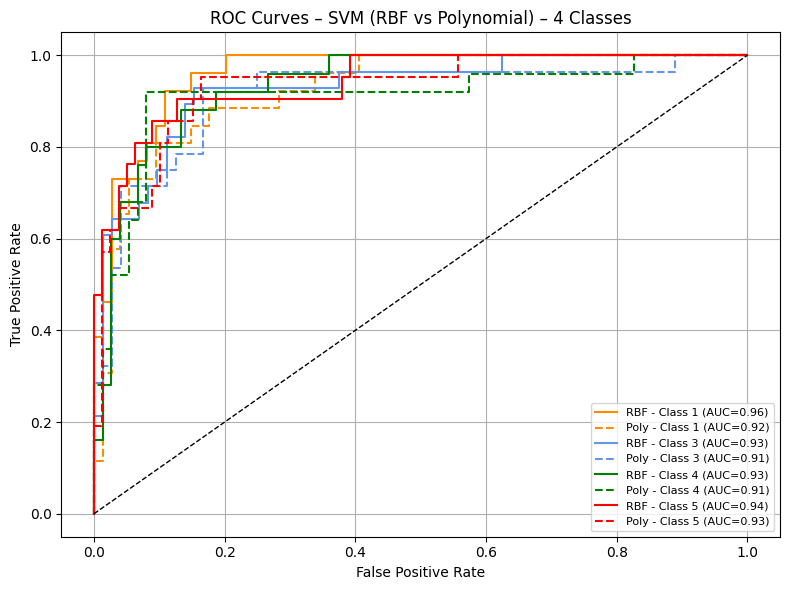

In [8]:
# ======================================================
# 🌊 ROC Curves for SVM + PCA (4-Class Classification)
# ======================================================

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------
# 1️⃣ Binarize the true labels for ROC
# --------------------------------------------
classes = np.unique(y_val)
n_classes = len(classes)
y_val_bin = label_binarize(y_val, classes=classes)

# --------------------------------------------
# 2️⃣ Get decision scores for both SVM models
# --------------------------------------------
# Enable probability=True in case it was not set earlier
svm_rbf_prob = SVC(kernel='rbf', C=1, gamma='scale', class_weight='balanced',
                   probability=True, random_state=42)
svm_rbf_prob.fit(X_train_pca, y_train)

svm_poly_prob = SVC(kernel='poly', degree=3, C=1, gamma='scale', class_weight='balanced',
                    probability=True, random_state=42)
svm_poly_prob.fit(X_train_pca, y_train)

# Predict probabilities on validation set
y_val_rbf = svm_rbf_prob.predict_proba(X_val_pca)
y_val_poly = svm_poly_prob.predict_proba(X_val_pca)

# --------------------------------------------
# 3️⃣ Plot ROC Curves
# --------------------------------------------
plt.figure(figsize=(8, 6))
colors = ['darkorange', 'cornflowerblue', 'green', 'red']

for i in range(n_classes):
    # RBF ROC
    fpr_rbf, tpr_rbf, _ = roc_curve(y_val_bin[:, i], y_val_rbf[:, i])
    auc_rbf = auc(fpr_rbf, tpr_rbf)
    plt.plot(fpr_rbf, tpr_rbf, color=colors[i],
             linestyle='-', label=f'RBF - Class {classes[i]} (AUC={auc_rbf:.2f})')

    # Poly ROC
    fpr_poly, tpr_poly, _ = roc_curve(y_val_bin[:, i], y_val_poly[:, i])
    auc_poly = auc(fpr_poly, tpr_poly)
    plt.plot(fpr_poly, tpr_poly, color=colors[i],
             linestyle='--', label=f'Poly - Class {classes[i]} (AUC={auc_poly:.2f})')

# --------------------------------------------
# 4️⃣ Final Touches
# --------------------------------------------
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.title('ROC Curves – SVM (RBF vs Polynomial) – 4 Classes')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right', fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()
